In [3]:
from pathlib import Path
import duckdb as db
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

In [4]:
from pathlib import Path

BASE = Path(r"C:\Users\Alejandro\Desktop\Uni Files\cbl_crime\DataStored")
PROCESSED = BASE / "processed"
PARQUET_PATH = PROCESSED / "crimes_clean_dedup_all_years.parquet"

print(PARQUET_PATH)
print(PARQUET_PATH.exists())

C:\Users\Alejandro\Desktop\Uni Files\cbl_crime\DataStored\processed\crimes_clean_dedup_all_years.parquet
True


In [5]:
#style

sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (12, 6)
plt.rcParams["axes.titlesize"] = 14
plt.rcParams["axes.labelsize"] = 12

In [6]:
#quick check

db.sql(f"""
SELECT *
FROM read_parquet('{PARQUET_PATH.as_posix()}')
LIMIT 5
""").df()

,Month,Falls within,Longitude,Latitude,LSOA code,LSOA name,Crime type
0,2013-05,Derbyshire Constabulary,-1.359885,53.014737,E01019438,Amber Valley 012C,Shoplifting
1,2013-05,Derbyshire Constabulary,-1.486916,52.981598,E01019426,Amber Valley 016B,Burglary
2,2013-05,Derbyshire Constabulary,-1.591089,52.941784,E01019472,Amber Valley 016D,Anti-social behaviour
3,2013-05,Derbyshire Constabulary,-1.353828,53.005095,E01019437,Amber Valley 017A,Criminal damage and arson
4,2013-05,Derbyshire Constabulary,-1.340087,53.022782,E01019452,Amber Valley 017C,Criminal damage and arson


In [7]:
#time range

db.sql(f"""
SELECT MIN("Month") AS min_month, MAX("Month") AS max_month
FROM read_parquet('{PARQUET_PATH.as_posix()}')
""").df()

,min_month,max_month
0,2010-12,2026-03


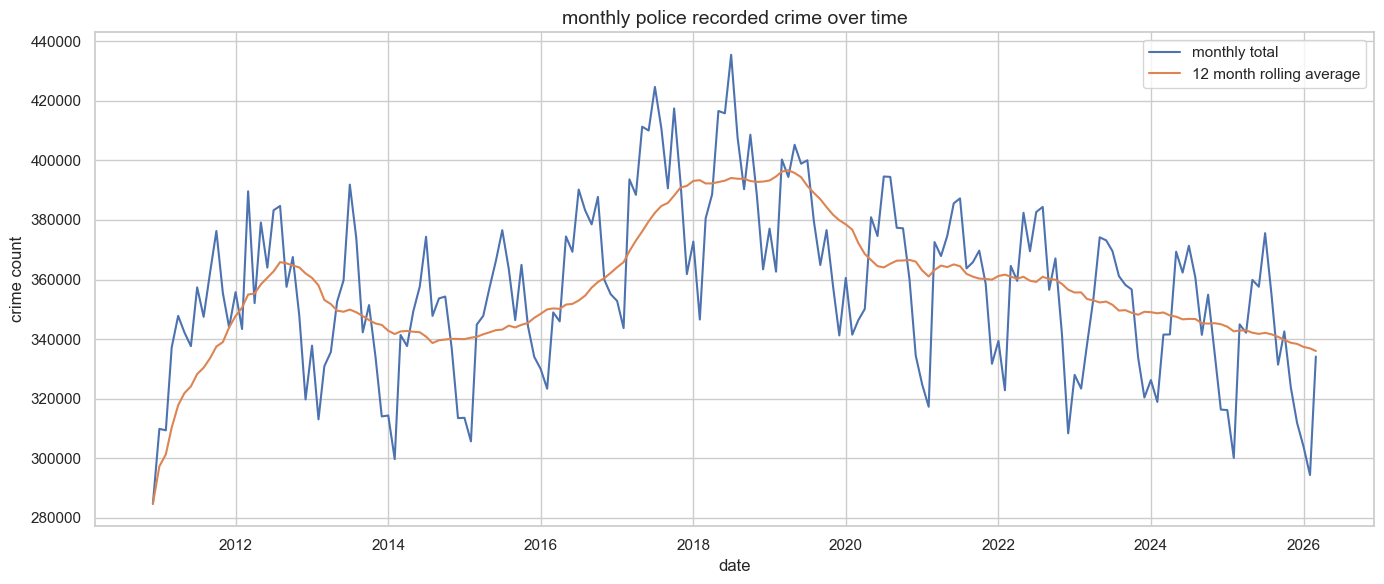

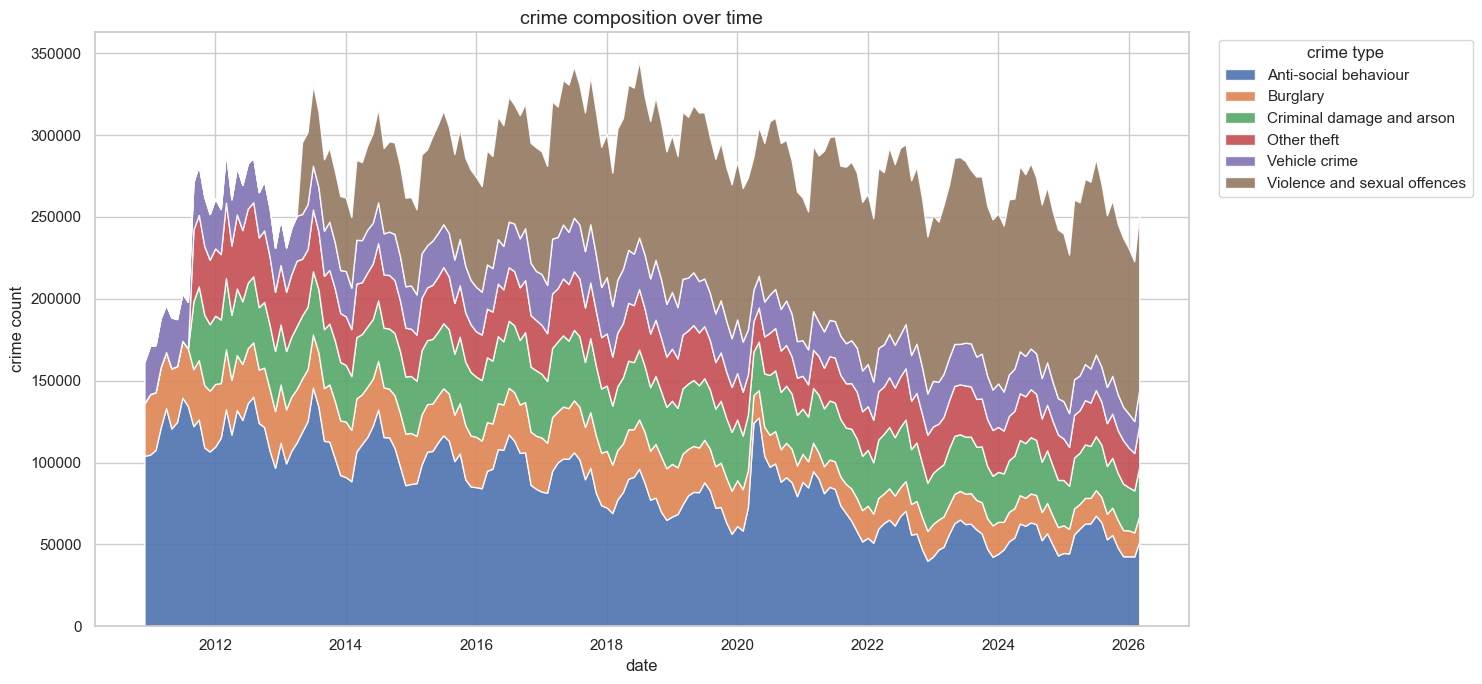

In [8]:
#monthly total crime trend 

monthly_total = db.sql(f"""
SELECT 
    "Month" AS month,
    COUNT(*) AS total_crimes
FROM read_parquet('{PARQUET_PATH.as_posix()}')
GROUP BY "Month"
ORDER BY "Month"
""").df()

monthly_total["month"] = pd.to_datetime(monthly_total["month"], format="%Y-%m")
monthly_total["rolling_12m"] = monthly_total["total_crimes"].rolling(12, min_periods=1).mean()

plt.figure(figsize=(14, 6))
sns.lineplot(data=monthly_total, x="month", y="total_crimes", label="monthly total")
sns.lineplot(data=monthly_total, x="month", y="rolling_12m", label="12 month rolling average")
plt.title("monthly police recorded crime over time")
plt.xlabel("date")
plt.ylabel("crime count")
plt.tight_layout()
plt.show()

#stacked area chart by crime category

monthly_by_type = db.sql(f"""
SELECT
    "Month" AS month,
    "Crime type" AS crime_type,
    COUNT(*) AS total_crimes
FROM read_parquet('{PARQUET_PATH.as_posix()}')
GROUP BY "Month", "Crime type"
""").df()

monthly_by_type["month"] = pd.to_datetime(monthly_by_type["month"], format="%Y-%m")

top_types_area = (
    monthly_by_type.groupby("crime_type", as_index=False)["total_crimes"]
    .sum()
    .sort_values("total_crimes", ascending=False)
    .head(6)["crime_type"]
    .tolist()
)

area_df = monthly_by_type[monthly_by_type["crime_type"].isin(top_types_area)].copy()
pivot_area = area_df.pivot(index="month", columns="crime_type", values="total_crimes").fillna(0)

plt.figure(figsize=(15, 7))
plt.stackplot(
    pivot_area.index,
    [pivot_area[col] for col in pivot_area.columns],
    labels=pivot_area.columns,
    alpha=0.9
)
plt.title("crime composition over time")
plt.xlabel("date")
plt.ylabel("crime count")
plt.legend(title="crime type", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()

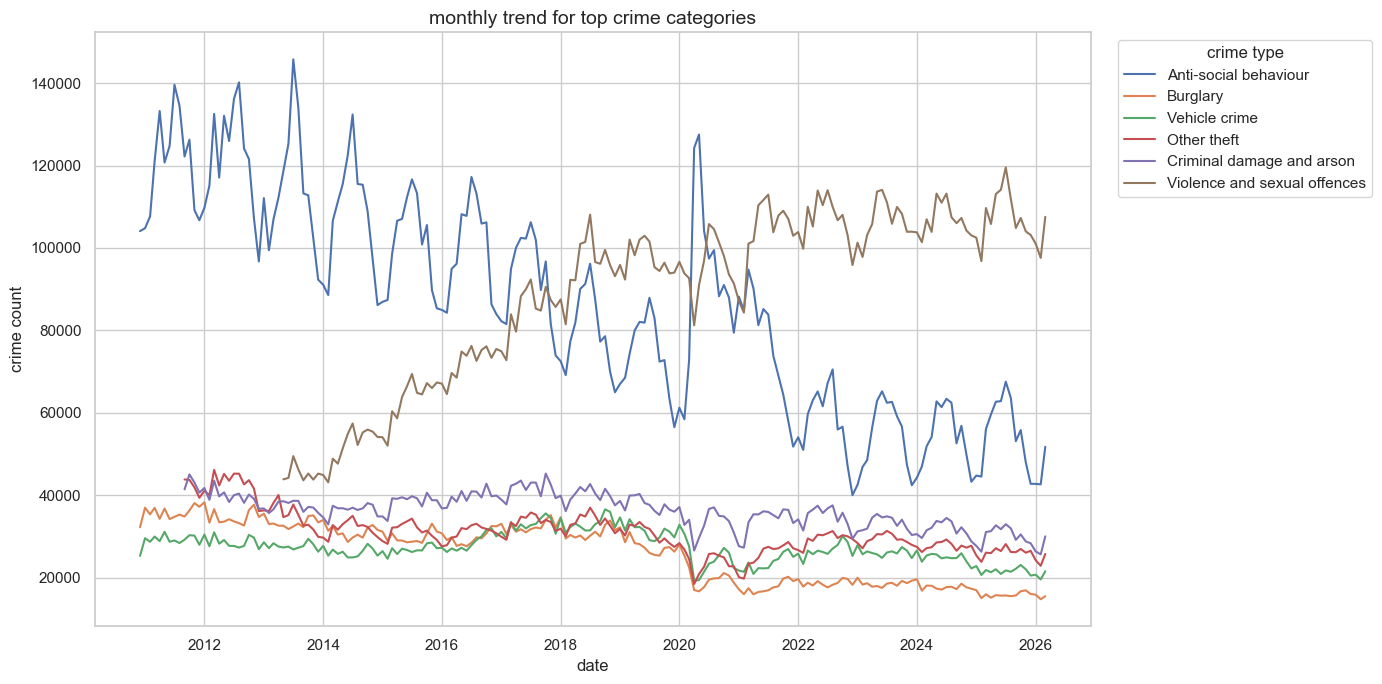

In [9]:
#monthly crime trend by category improved

monthly_by_type = db.sql(f"""
SELECT
    "Month" AS month,
    "Crime type" AS crime_type,
    COUNT(*) AS total_crimes
FROM read_parquet('{PARQUET_PATH.as_posix()}')
GROUP BY "Month", "Crime type"
ORDER BY "Month", total_crimes DESC
""").df()

monthly_by_type["month"] = pd.to_datetime(monthly_by_type["month"], format="%Y-%m")

top_types = (
    monthly_by_type.groupby("crime_type", as_index=False)["total_crimes"]
    .sum()
    .sort_values("total_crimes", ascending=False)
    .head(6)["crime_type"]
    .tolist()
)

monthly_top_types = monthly_by_type[monthly_by_type["crime_type"].isin(top_types)].copy()

plt.figure(figsize=(14, 7))
sns.lineplot(data=monthly_top_types, x="month", y="total_crimes", hue="crime_type")
plt.title("monthly trend for top crime categories")
plt.xlabel("date")
plt.ylabel("crime count")
plt.legend(title="crime type", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()

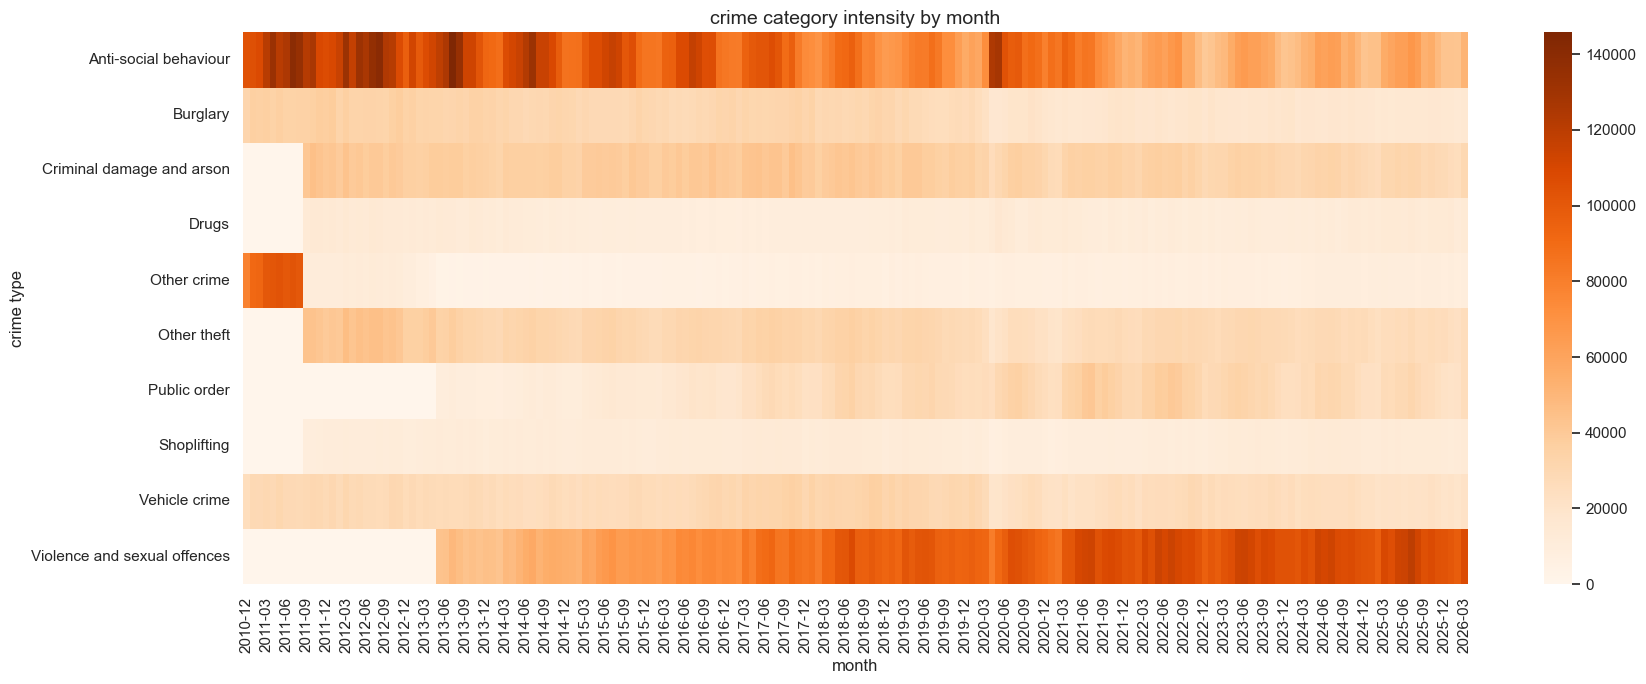

In [10]:
#crime category by month heatmap

heatmap_df = db.sql(f"""
SELECT
    "Month" AS month,
    "Crime type" AS crime_type,
    COUNT(*) AS total_crimes
FROM read_parquet('{PARQUET_PATH.as_posix()}')
GROUP BY "Month", "Crime type"
""").df()

heatmap_df["month"] = pd.to_datetime(heatmap_df["month"], format="%Y-%m")
heatmap_df["month_str"] = heatmap_df["month"].dt.strftime("%Y-%m")

top_types_heat = (
    heatmap_df.groupby("crime_type", as_index=False)["total_crimes"]
    .sum()
    .sort_values("total_crimes", ascending=False)
    .head(10)["crime_type"]
    .tolist()
)

heatmap_plot_df = heatmap_df[heatmap_df["crime_type"].isin(top_types_heat)].copy()
pivot_heat = heatmap_plot_df.pivot(index="crime_type", columns="month_str", values="total_crimes").fillna(0)

plt.figure(figsize=(18, 7))
sns.heatmap(pivot_heat, cmap="Oranges")
plt.title("crime category intensity by month")
plt.xlabel("month")
plt.ylabel("crime type")
plt.tight_layout()
plt.show()

In [11]:
####checking data based on the heatmap

#check when each crime type appears

crime_type_coverage = db.sql(f"""
SELECT
    "Crime type" AS crime_type,
    MIN("Month") AS first_month,
    MAX("Month") AS last_month,
    COUNT(*) AS total_rows
FROM read_parquet('{PARQUET_PATH.as_posix()}')
GROUP BY "Crime type"
ORDER BY first_month, crime_type
""").df()

crime_type_coverage



,crime_type,first_month,last_month,total_rows
0,Anti-social behaviour,2010-12,2026-03,15849458
1,Burglary,2010-12,2026-03,4813996
2,Other crime,2010-12,2026-03,2162898
3,Robbery,2010-12,2026-03,896431
4,Vehicle crime,2010-12,2026-03,5023592
5,Violent crime,2010-12,2013-04,1227238
6,Criminal damage and arson,2011-09,2026-03,6341518
7,Drugs,2011-09,2026-03,2045619
8,Other theft,2011-09,2026-03,5412595
9,Public disorder and weapons,2011-09,2013-04,201231


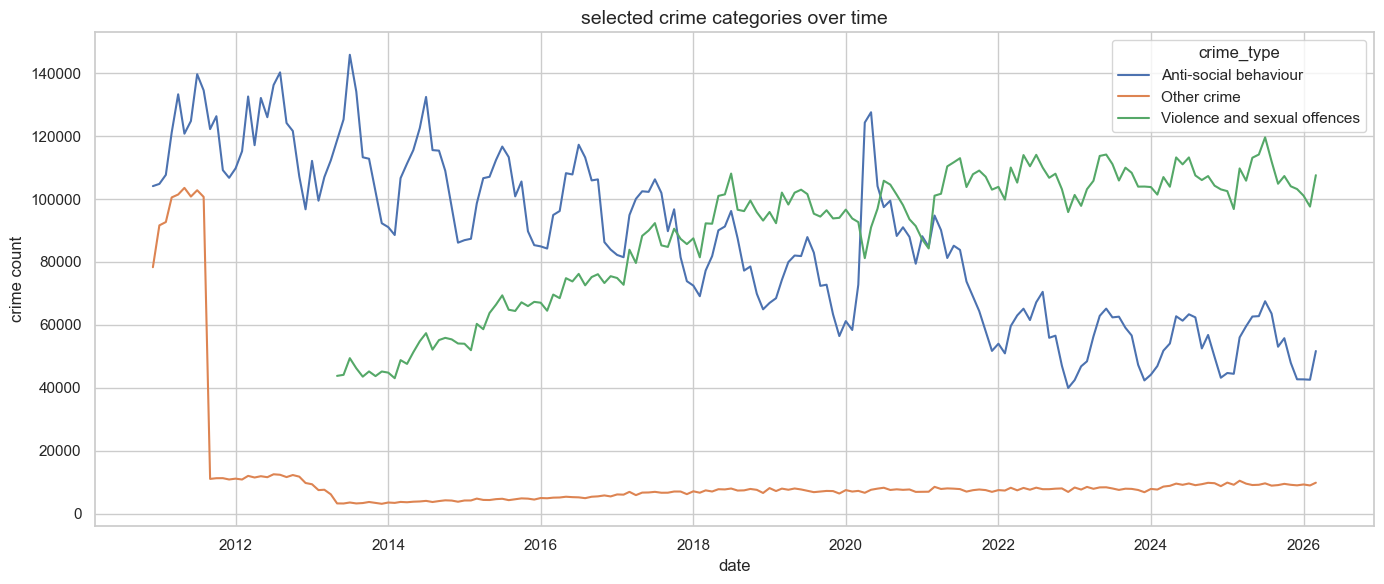

In [12]:

#inspect specific categories over time

specific_types = db.sql(f"""
SELECT
    "Month" AS month,
    "Crime type" AS crime_type,
    COUNT(*) AS total_crimes
FROM read_parquet('{PARQUET_PATH.as_posix()}')
WHERE "Crime type" IN ('Other crime', 'Violence and sexual offences', 'Anti-social behaviour')
GROUP BY "Month", "Crime type"
ORDER BY "Month", "Crime type"
""").df()

specific_types["month"] = pd.to_datetime(specific_types["month"], format="%Y-%m")

plt.figure(figsize=(14, 6))
sns.lineplot(data=specific_types, x="month", y="total_crimes", hue="crime_type")
plt.title("selected crime categories over time")
plt.xlabel("date")
plt.ylabel("crime count")
plt.tight_layout()
plt.show()


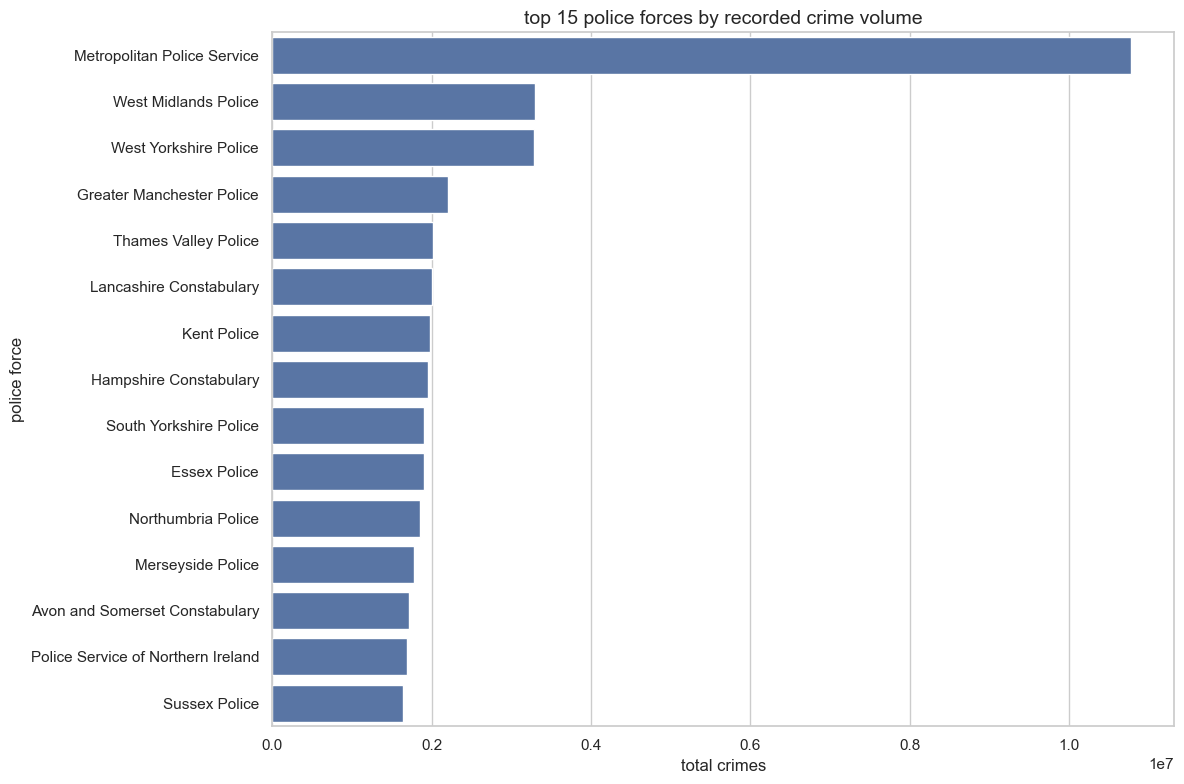

In [13]:
#force level total crime comparison

force_totals = db.sql(f"""
SELECT
    "Falls within" AS police_force,
    COUNT(*) AS total_crimes
FROM read_parquet('{PARQUET_PATH.as_posix()}')
GROUP BY "Falls within"
ORDER BY total_crimes DESC
""").df()

top_forces = force_totals.head(15).copy()

plt.figure(figsize=(12, 8))
sns.barplot(data=top_forces, y="police_force", x="total_crimes", orient="h")
plt.title("top 15 police forces by recorded crime volume")
plt.xlabel("total crimes")
plt.ylabel("police force")
plt.tight_layout()
plt.show()

In [14]:
#average crimes per lsoa within force

force_lsoa_stats = db.sql(f"""
WITH lsoa_force_counts AS (
    SELECT
        "Falls within" AS police_force,
        "LSOA code" AS lsoa_code,
        COUNT(*) AS total_crimes
    FROM read_parquet('{PARQUET_PATH.as_posix()}')
    WHERE "LSOA code" IS NOT NULL
    GROUP BY "Falls within", "LSOA code"
)
SELECT
    police_force,
    COUNT(*) AS n_lsoas,
    AVG(total_crimes) AS avg_crimes_per_lsoa,
    SUM(total_crimes) AS total_crimes
FROM lsoa_force_counts
GROUP BY police_force
ORDER BY total_crimes DESC
""").df()

force_lsoa_stats.head(15)

,police_force,n_lsoas,avg_crimes_per_lsoa,total_crimes
0,Metropolitan Police Service,16628,648.180118,10777939.0
1,West Midlands Police,2116,1558.203214,3297158.0
2,West Yorkshire Police,1620,2026.463580,3282871.0
3,Greater Manchester Police,1710,1290.584211,2206899.0
4,Thames Valley Police,1669,1208.629119,2017202.0
5,Lancashire Constabulary,3191,628.172987,2004500.0
6,Kent Police,2429,814.906958,1979409.0
7,Hampshire Constabulary,1908,1027.223795,1959943.0
8,South Yorkshire Police,1876,1013.962687,1902194.0
9,Essex Police,2684,706.974665,1897520.0


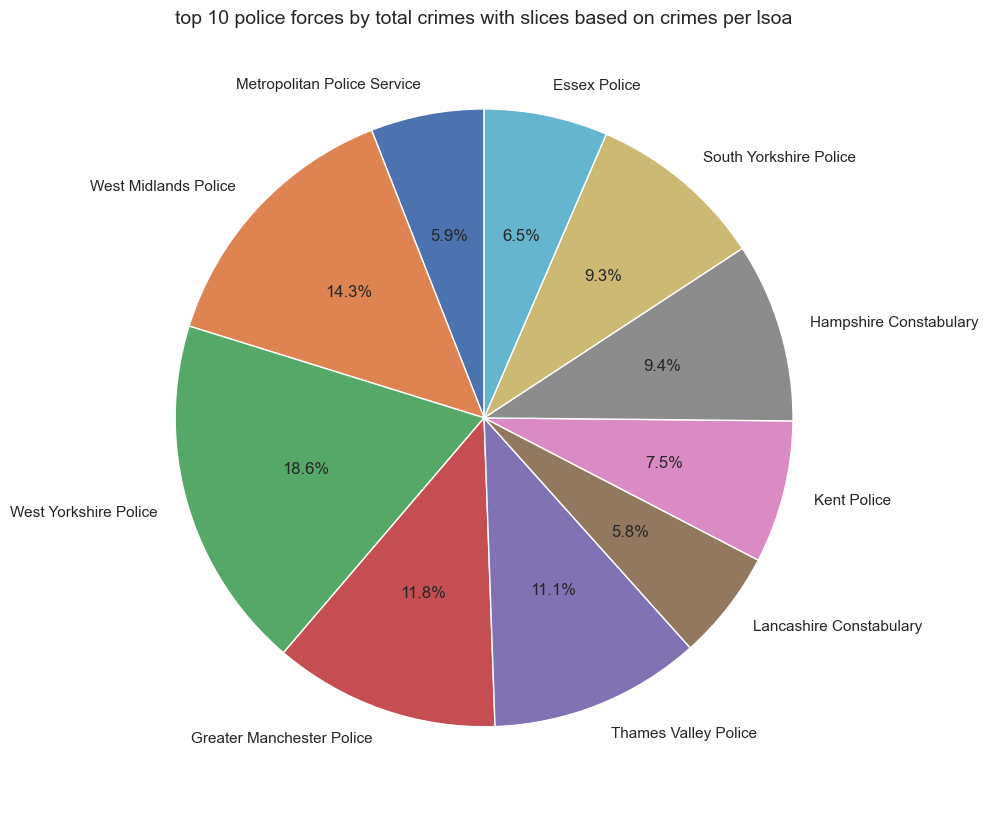

In [35]:
#explicit normalization check

top10_force_lsoa_stats = force_lsoa_stats.head(10).copy()
top10_force_lsoa_stats["crimes_per_lsoa"] = (
    top10_force_lsoa_stats["total_crimes"] / top10_force_lsoa_stats["n_lsoas"]
)
top10_force_lsoa_stats["normalized_share"] = (
    top10_force_lsoa_stats["crimes_per_lsoa"] /
    top10_force_lsoa_stats["crimes_per_lsoa"].sum()
)

plt.figure(figsize=(10, 10))
plt.pie(
    top10_force_lsoa_stats["normalized_share"],
    labels=top10_force_lsoa_stats["police_force"],
    autopct="%1.1f%%",
    startangle=90
)
plt.title("top 10 police forces by total crimes with slices based on crimes per lsoa")
plt.tight_layout()
plt.show()

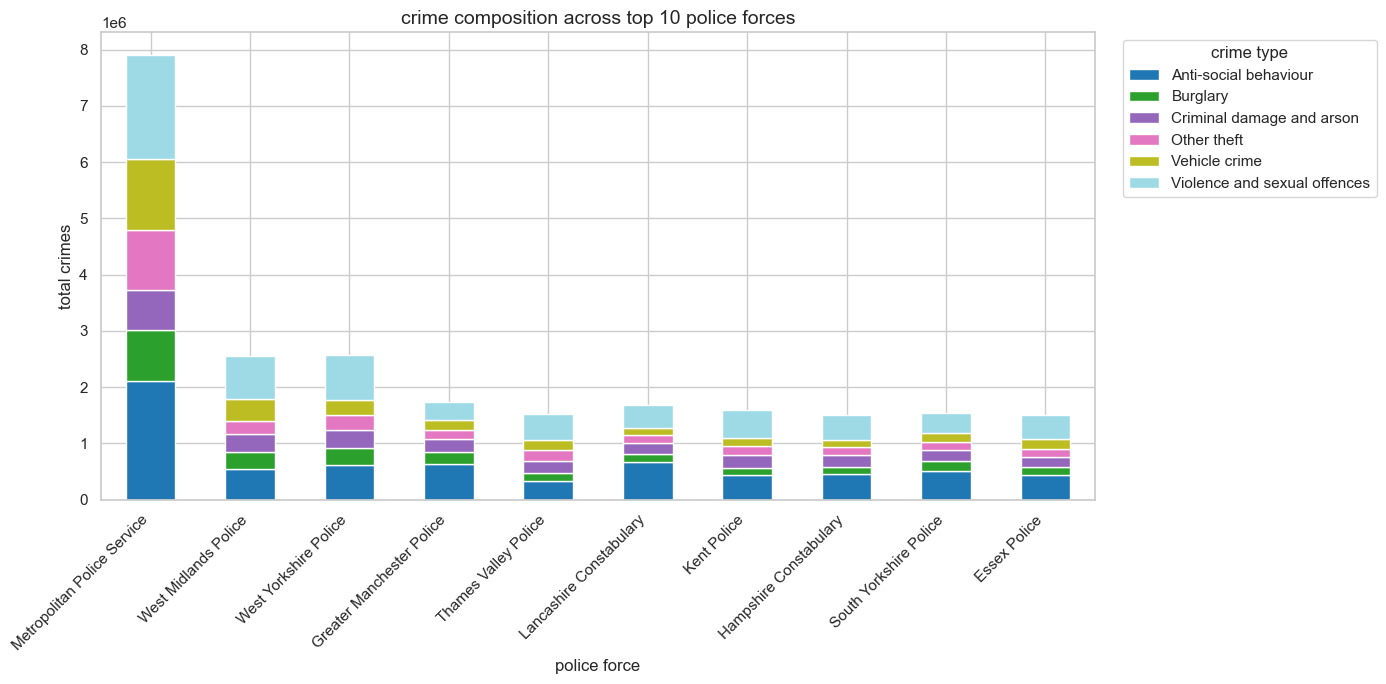

In [15]:
#force crime composition stacked bar

force_type = db.sql(f"""
SELECT
    "Falls within" AS police_force,
    "Crime type" AS crime_type,
    COUNT(*) AS total_crimes
FROM read_parquet('{PARQUET_PATH.as_posix()}')
GROUP BY "Falls within", "Crime type"
""").df()

top_force_names = force_totals.head(10)["police_force"].tolist()
top_type_names = (
    force_type.groupby("crime_type", as_index=False)["total_crimes"]
    .sum()
    .sort_values("total_crimes", ascending=False)
    .head(6)["crime_type"]
    .tolist()
)

force_type_plot = force_type[
    force_type["police_force"].isin(top_force_names) &
    force_type["crime_type"].isin(top_type_names)
].copy()

pivot_force_type = force_type_plot.pivot(index="police_force", columns="crime_type", values="total_crimes").fillna(0)
pivot_force_type = pivot_force_type.loc[top_force_names]

pivot_force_type.plot(kind="bar", stacked=True, figsize=(14, 7), colormap="tab20")
plt.title("crime composition across top 10 police forces")
plt.xlabel("police force")
plt.ylabel("total crimes")
plt.xticks(rotation=45, ha="right")
plt.legend(title="crime type", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()

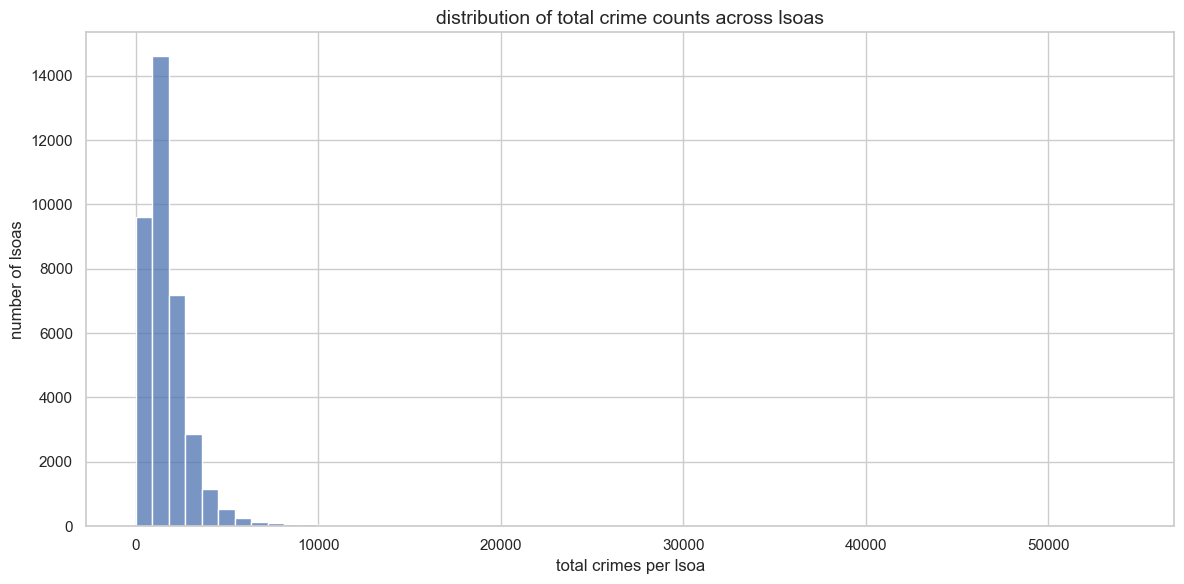

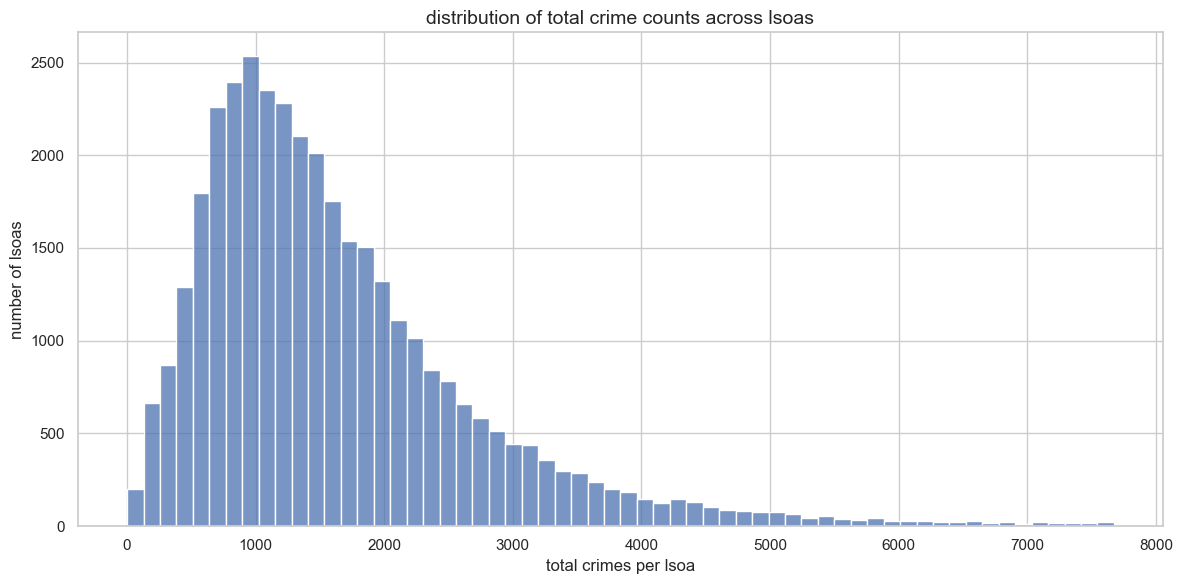

In [16]:
#distribution of crime across lsoas

lsoa_counts = db.sql(f"""
SELECT
    "LSOA code" AS lsoa_code,
    COUNT(*) AS total_crimes
FROM read_parquet('{PARQUET_PATH.as_posix()}')
WHERE "LSOA code" IS NOT NULL
GROUP BY "LSOA code"
""").df()

plt.figure(figsize=(12, 6))
sns.histplot(lsoa_counts["total_crimes"], bins=60)
plt.title("distribution of total crime counts across lsoas")
plt.xlabel("total crimes per lsoa")
plt.ylabel("number of lsoas")
plt.tight_layout()
plt.show()

#distribution with capped x axis

x_cap = lsoa_counts["total_crimes"].quantile(0.99)

plt.figure(figsize=(12, 6))
sns.histplot(lsoa_counts[lsoa_counts["total_crimes"] <= x_cap]["total_crimes"], bins=60)
plt.title("distribution of total crime counts across lsoas")
plt.xlabel("total crimes per lsoa")
plt.ylabel("number of lsoas")
plt.tight_layout()
plt.show()

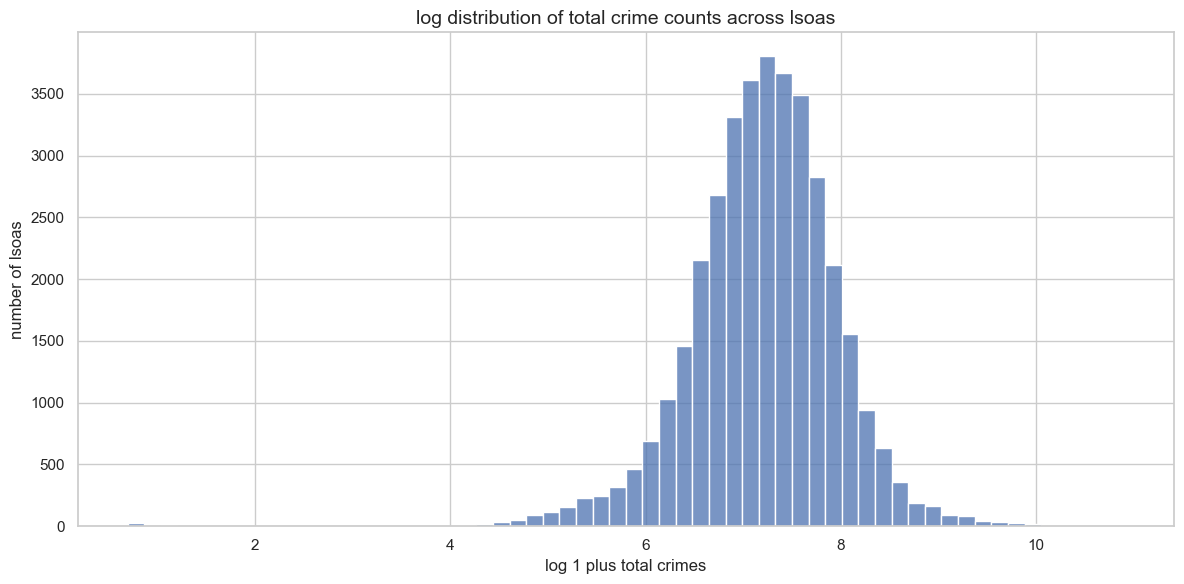

In [17]:
#log distribution of crime across lsoas

lsoa_counts["log_total_crimes"] = np.log1p(lsoa_counts["total_crimes"])

plt.figure(figsize=(12, 6))
sns.histplot(lsoa_counts["log_total_crimes"], bins=60)
plt.title("log distribution of total crime counts across lsoas")
plt.xlabel("log 1 plus total crimes")
plt.ylabel("number of lsoas")
plt.tight_layout()
plt.show()

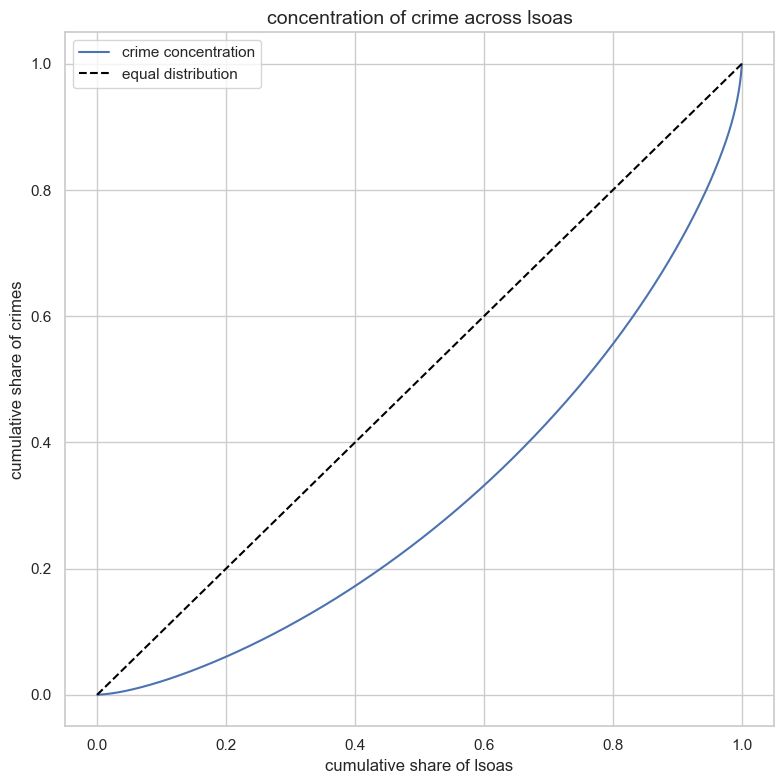

NameError: name 'concentration_summary' is not defined

In [18]:
#lorenz style concentration plot

lsoa_sorted = lsoa_counts.sort_values("total_crimes").reset_index(drop=True).copy()
lsoa_sorted["cum_lsoas"] = np.arange(1, len(lsoa_sorted) + 1) / len(lsoa_sorted)
lsoa_sorted["cum_crimes"] = lsoa_sorted["total_crimes"].cumsum() / lsoa_sorted["total_crimes"].sum()

plt.figure(figsize=(8, 8))
plt.plot(lsoa_sorted["cum_lsoas"], lsoa_sorted["cum_crimes"], label="crime concentration")
plt.plot([0, 1], [0, 1], linestyle="--", color="black", label="equal distribution")
plt.title("concentration of crime across lsoas")
plt.xlabel("cumulative share of lsoas")
plt.ylabel("cumulative share of crimes")
plt.legend()
plt.tight_layout()
plt.show()

#plot concentration summary

concentration_summary["top_share_lsoas_label"] = (concentration_summary["top_share_lsoas"] * 100).astype(int).astype(str) + "%"

plt.figure(figsize=(8, 5))
sns.barplot(data=concentration_summary, x="top_share_lsoas_label", y="crime_share")
plt.title("share of total crime accounted for by top lsoas")
plt.xlabel("top share of lsoas")
plt.ylabel("share of total crimes")
plt.tight_layout()
plt.show()

In [ ]:
#top x percent concentration

lsoa_desc = lsoa_counts.sort_values("total_crimes", ascending=False).reset_index(drop=True).copy()
lsoa_desc["cum_crimes"] = lsoa_desc["total_crimes"].cumsum() / lsoa_desc["total_crimes"].sum()
lsoa_desc["cum_lsoas"] = (np.arange(len(lsoa_desc)) + 1) / len(lsoa_desc)

thresholds = [0.01, 0.05, 0.10, 0.20]
summary_rows = []

for t in thresholds:
    n = max(1, int(len(lsoa_desc) * t))
    share = lsoa_desc.iloc[:n]["total_crimes"].sum() / lsoa_desc["total_crimes"].sum()
    summary_rows.append({"top_share_lsoas": t, "crime_share": share})

concentration_summary = pd.DataFrame(summary_rows)
concentration_summary

,top_share_lsoas,crime_share
0,0.01,0.070412
1,0.05,0.188388
2,0.10,0.289198
3,0.20,0.444159


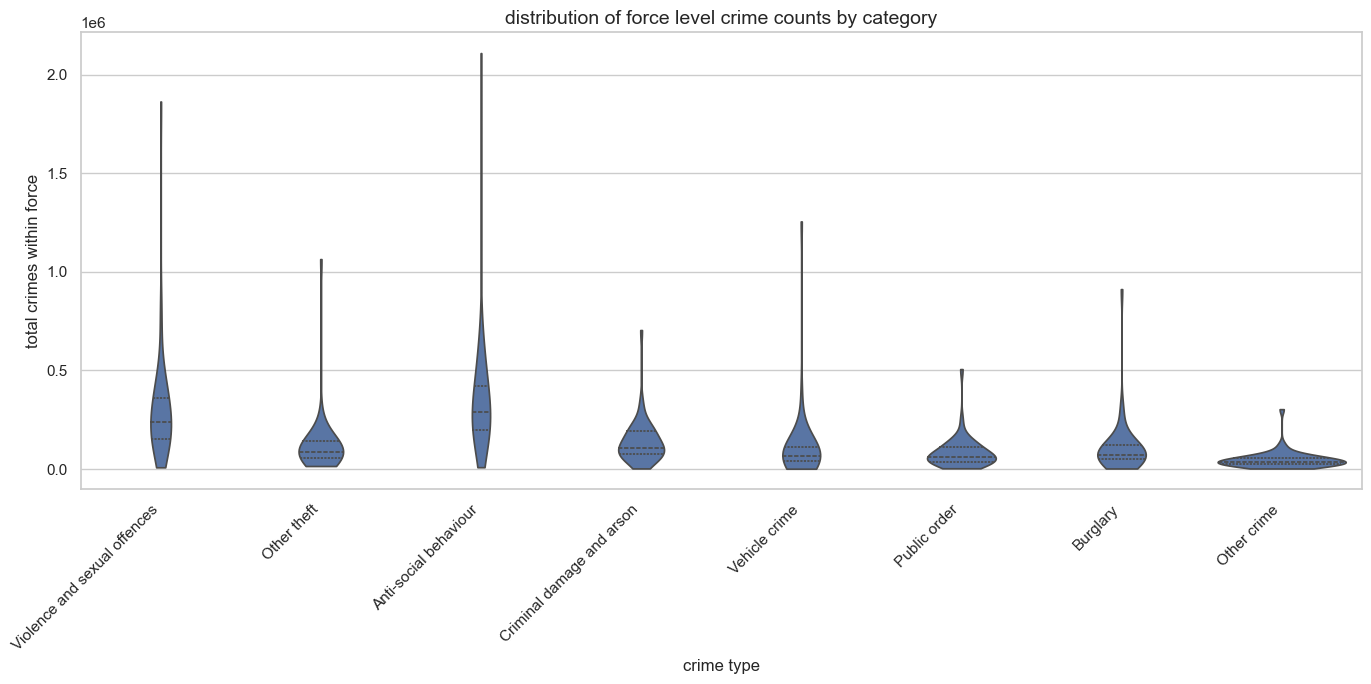

In [ ]:
#crime category violin plot across forces

force_type_counts = db.sql(f"""
SELECT
    "Falls within" AS police_force,
    "Crime type" AS crime_type,
    COUNT(*) AS total_crimes
FROM read_parquet('{PARQUET_PATH.as_posix()}')
GROUP BY "Falls within", "Crime type"
""").df()

top_violin_types = (
    force_type_counts.groupby("crime_type", as_index=False)["total_crimes"]
    .sum()
    .sort_values("total_crimes", ascending=False)
    .head(8)["crime_type"]
    .tolist()
)

violin_df = force_type_counts[force_type_counts["crime_type"].isin(top_violin_types)].copy()

plt.figure(figsize=(14, 7))
sns.violinplot(data=violin_df, x="crime_type", y="total_crimes", inner="quartile", cut=0)
plt.title("distribution of force level crime counts by category")
plt.xlabel("crime type")
plt.ylabel("total crimes within force")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

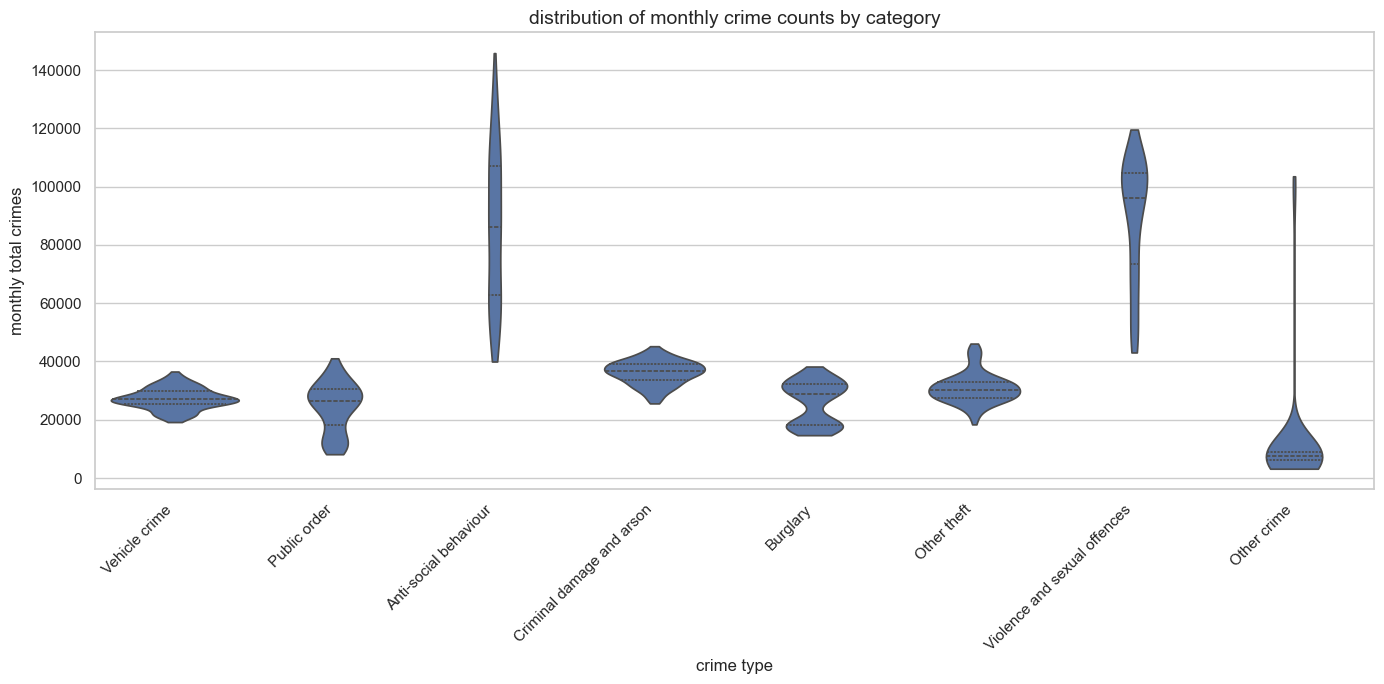

In [ ]:
#monthly crime distribution by category using violin

monthly_type_counts = db.sql(f"""
SELECT
    "Month" AS month,
    "Crime type" AS crime_type,
    COUNT(*) AS total_crimes
FROM read_parquet('{PARQUET_PATH.as_posix()}')
GROUP BY "Month", "Crime type"
""").df()

top_monthly_violin_types = (
    monthly_type_counts.groupby("crime_type", as_index=False)["total_crimes"]
    .sum()
    .sort_values("total_crimes", ascending=False)
    .head(8)["crime_type"]
    .tolist()
)

monthly_violin_df = monthly_type_counts[
    monthly_type_counts["crime_type"].isin(top_monthly_violin_types)
].copy()

plt.figure(figsize=(14, 7))
sns.violinplot(data=monthly_violin_df, x="crime_type", y="total_crimes", inner="quartile", cut=0)
plt.title("distribution of monthly crime counts by category")
plt.xlabel("crime type")
plt.ylabel("monthly total crimes")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

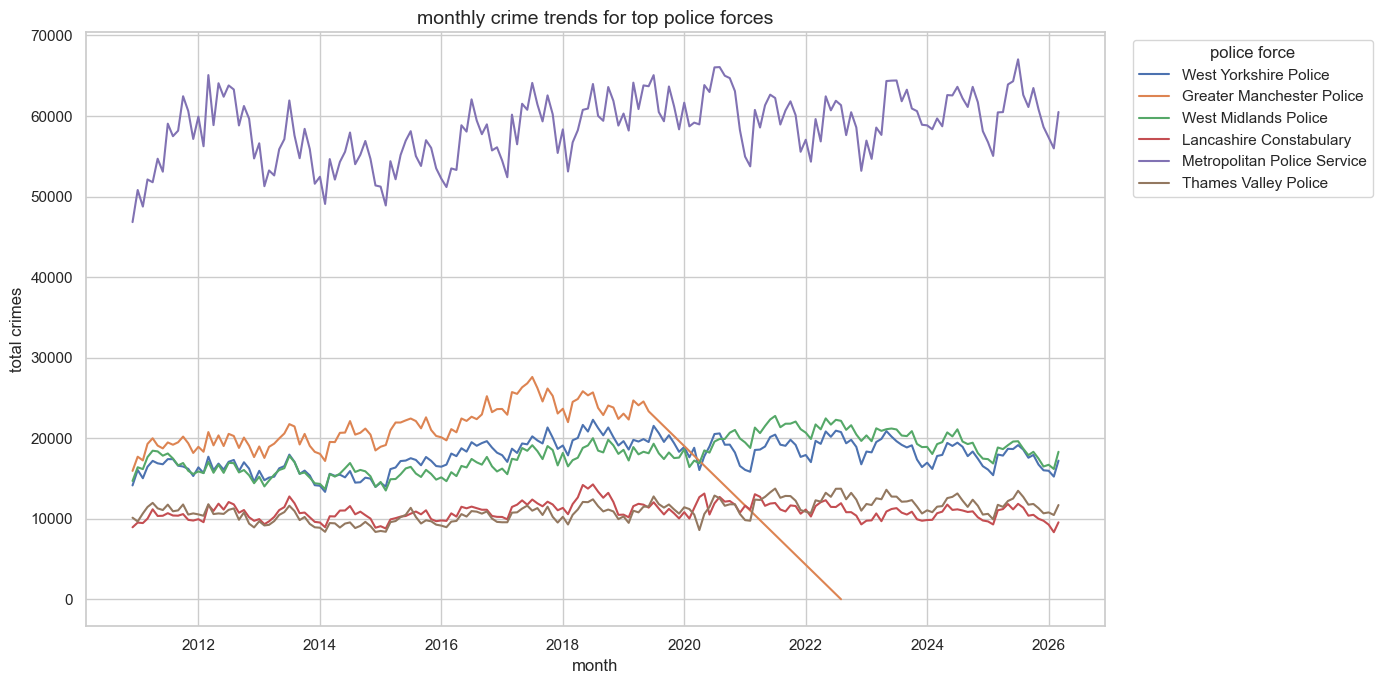

In [ ]:
#top forces over time

monthly_force = db.sql(f"""
SELECT
    "Month" AS month,
    "Falls within" AS police_force,
    COUNT(*) AS total_crimes
FROM read_parquet('{PARQUET_PATH.as_posix()}')
GROUP BY "Month", "Falls within"
""").df()

monthly_force["month"] = pd.to_datetime(monthly_force["month"], format="%Y-%m")

top_force_names_time = (
    monthly_force.groupby("police_force", as_index=False)["total_crimes"]
    .sum()
    .sort_values("total_crimes", ascending=False)
    .head(6)["police_force"]
    .tolist()
)

monthly_force_plot = monthly_force[monthly_force["police_force"].isin(top_force_names_time)].copy()

plt.figure(figsize=(14, 7))
sns.lineplot(data=monthly_force_plot, x="month", y="total_crimes", hue="police_force")
plt.title("monthly crime trends for top police forces")
plt.xlabel("month")
plt.ylabel("total crimes")
plt.legend(title="police force", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()

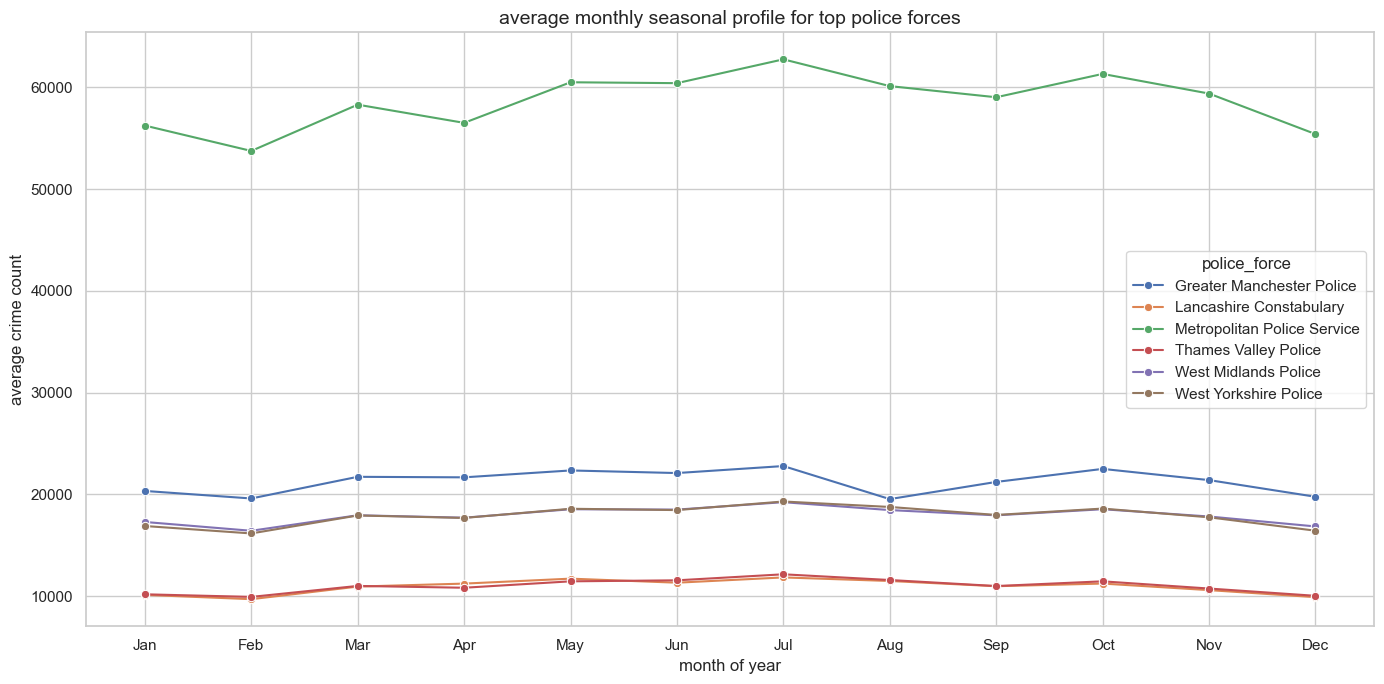

In [ ]:
#seasonal profile by force

monthly_force = db.sql(f"""
SELECT
    "Month" AS month,
    "Falls within" AS police_force,
    COUNT(*) AS total_crimes
FROM read_parquet('{PARQUET_PATH.as_posix()}')
GROUP BY "Month", "Falls within"
""").df()

monthly_force["month"] = pd.to_datetime(monthly_force["month"], format="%Y-%m")
monthly_force["year"] = monthly_force["month"].dt.year
monthly_force["month_num"] = monthly_force["month"].dt.month
monthly_force["month_name"] = monthly_force["month"].dt.strftime("%b")

top_force_names_time = (
    monthly_force.groupby("police_force", as_index=False)["total_crimes"]
    .sum()
    .sort_values("total_crimes", ascending=False)
    .head(6)["police_force"]
    .tolist()
)

seasonal_force = (
    monthly_force[monthly_force["police_force"].isin(top_force_names_time)]
    .groupby(["police_force", "month_num", "month_name"], as_index=False)["total_crimes"]
    .mean()
)

month_order = ["Jan", "Feb", "Mar", "Apr", "May", "Jun",
               "Jul", "Aug", "Sep", "Oct", "Nov", "Dec"]

seasonal_force["month_name"] = pd.Categorical(
    seasonal_force["month_name"],
    categories=month_order,
    ordered=True
)

plt.figure(figsize=(14, 7))
sns.lineplot(data=seasonal_force, x="month_name", y="total_crimes", hue="police_force", marker="o")
plt.title("average monthly seasonal profile for top police forces")
plt.xlabel("month of year")
plt.ylabel("average crime count")
plt.tight_layout()
plt.show()

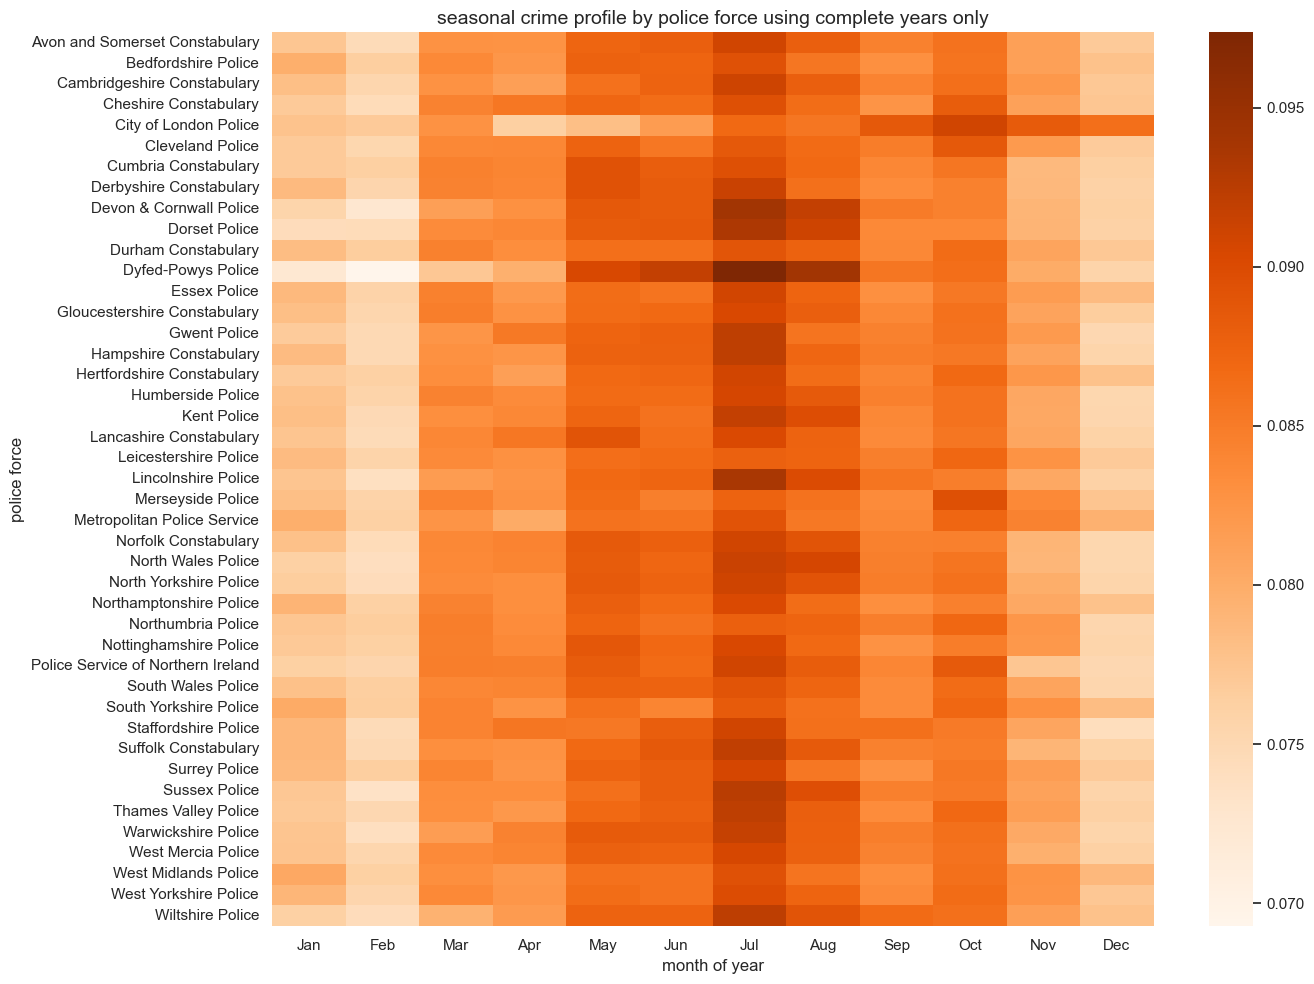

In [30]:
#force year month counts

monthly_force = db.sql(f"""
SELECT
    "Month" AS month,
    "Falls within" AS police_force,
    COUNT(*) AS total_crimes
FROM read_parquet('{PARQUET_PATH.as_posix()}')
GROUP BY "Month", "Falls within"
""").df()

monthly_force["month"] = pd.to_datetime(monthly_force["month"], format="%Y-%m")
monthly_force["year"] = monthly_force["month"].dt.year
monthly_force["month_num"] = monthly_force["month"].dt.month
monthly_force["month_name"] = monthly_force["month"].dt.strftime("%b")

#keep only complete force years

force_year_month_counts = (
    monthly_force.groupby(["police_force", "year"], as_index=False)["month_num"]
    .nunique()
    .rename(columns={"month_num": "n_months"})
)

complete_force_years = force_year_month_counts[
    force_year_month_counts["n_months"] == 12
][["police_force", "year"]].copy()

monthly_force_complete = monthly_force.merge(
    complete_force_years,
    on=["police_force", "year"],
    how="inner"
)

monthly_force_complete.head()

#optional exclusions

monthly_force_complete = monthly_force_complete[
    ~monthly_force_complete["police_force"].isin([
        "Greater Manchester Police",
        "British Transport Police"
    ])
].copy()


#monthly share within complete force years

force_year_totals = (
    monthly_force_complete.groupby(["police_force", "year"], as_index=False)["total_crimes"]
    .sum()
    .rename(columns={"total_crimes": "year_total"})
)

force_year_month = monthly_force_complete.merge(
    force_year_totals,
    on=["police_force", "year"],
    how="left"
)

force_year_month["monthly_share"] = force_year_month["total_crimes"] / force_year_month["year_total"]

#average seasonal profile by force

month_order = ["Jan", "Feb", "Mar", "Apr", "May", "Jun",
               "Jul", "Aug", "Sep", "Oct", "Nov", "Dec"]

seasonal_profile_force = (
    force_year_month.groupby(["police_force", "month_num", "month_name"], as_index=False)["monthly_share"]
    .mean()
)

seasonal_profile_force["month_name"] = pd.Categorical(
    seasonal_profile_force["month_name"],
    categories=month_order,
    ordered=True
)

#seasonal heatmap by force corrected

pivot_seasonal_force = seasonal_profile_force.pivot(
    index="police_force",
    columns="month_name",
    values="monthly_share"
).fillna(0)

pivot_seasonal_force = pivot_seasonal_force[month_order]

plt.figure(figsize=(14, 10))
sns.heatmap(pivot_seasonal_force, cmap="Oranges")
plt.title("seasonal crime profile by police force using complete years only")
plt.xlabel("month of year")
plt.ylabel("police force")
plt.tight_layout()
plt.show()

In [31]:
#summer minus winter corrected

seasonal_summary = (
    seasonal_profile_force.groupby("police_force")
    .apply(lambda g: pd.Series({
        "summer_share": g[g["month_num"].isin([6, 7, 8])]["monthly_share"].sum(),
        "winter_share": g[g["month_num"].isin([12, 1, 2])]["monthly_share"].sum(),
        "summer_minus_winter": g[g["month_num"].isin([6, 7, 8])]["monthly_share"].sum()
                              - g[g["month_num"].isin([12, 1, 2])]["monthly_share"].sum()
    }))
    .reset_index()
    .sort_values("summer_minus_winter", ascending=False)
)

seasonal_summary

,police_force,summer_share,winter_share,summer_minus_winter
11,Dyfed-Powys Police,0.283398,0.217345,0.066054
8,Devon & Cornwall Police,0.274154,0.224435,0.049719
9,Dorset Police,0.272913,0.224880,0.048033
36,Sussex Police,0.270154,0.226437,0.043717
25,North Wales Police,0.269038,0.225477,0.043561
21,Lincolnshire Police,0.270718,0.227262,0.043456
26,North Yorkshire Police,0.267648,0.226499,0.041149
38,Warwickshire Police,0.267567,0.226867,0.040700
42,Wiltshire Police,0.268771,0.228306,0.040464
24,Norfolk Constabulary,0.267729,0.227587,0.040142


In [33]:
#national seasonal profile corrected

national_month = (
    force_year_month.groupby(["year", "month_num", "month_name"], as_index=False)["total_crimes"]
    .sum()
)

national_year_total = (
    national_month.groupby("year", as_index=False)["total_crimes"]
    .sum()
    .rename(columns={"total_crimes": "year_total"})
)

national_month = national_month.merge(national_year_total, on="year", how="left")
national_month["monthly_share"] = national_month["total_crimes"] / national_month["year_total"]

national_profile = (
    national_month.groupby(["month_num", "month_name"], as_index=False)["monthly_share"]
    .mean()
)

#correlation with national seasonal profile corrected

national_vec = national_profile.sort_values("month_num")["monthly_share"].to_numpy()

force_corr_rows = []

for force, group in seasonal_profile_force.groupby("police_force"):
    vec = group.sort_values("month_num")["monthly_share"].to_numpy()
    corr = np.corrcoef(vec, national_vec)[0, 1]
    force_corr_rows.append({
        "police_force": force,
        "seasonal_corr_with_national": corr
    })

force_corr_df = pd.DataFrame(force_corr_rows).sort_values(
    "seasonal_corr_with_national",
    ascending=False
)

force_corr_df

,police_force,seasonal_corr_with_national
0,Avon and Somerset Constabulary,0.995742
41,West Yorkshire Police,0.994934
37,Thames Valley Police,0.994718
13,Gloucestershire Constabulary,0.992741
2,Cambridgeshire Constabulary,0.990053
15,Hampshire Constabulary,0.989667
26,North Yorkshire Police,0.989456
10,Durham Constabulary,0.988227
16,Hertfordshire Constabulary,0.987225
17,Humberside Police,0.986764


In [34]:
#compact seasonality summary table

n_forces = len(seasonal_summary)
n_positive = (seasonal_summary["summer_minus_winter"] > 0).sum()
median_gap = seasonal_summary["summer_minus_winter"].median()
mean_gap = seasonal_summary["summer_minus_winter"].mean()

top_gap_force = seasonal_summary.iloc[0]["police_force"]
top_gap_value = seasonal_summary.iloc[0]["summer_minus_winter"]

bottom_gap_force = seasonal_summary.iloc[-1]["police_force"]
bottom_gap_value = seasonal_summary.iloc[-1]["summer_minus_winter"]

median_corr = force_corr_df["seasonal_corr_with_national"].median()
mean_corr = force_corr_df["seasonal_corr_with_national"].mean()

lowest_corr_force = force_corr_df.iloc[-1]["police_force"]
lowest_corr_value = force_corr_df.iloc[-1]["seasonal_corr_with_national"]

summary_table = pd.DataFrame({
    "metric": [
        "forces with summer > winter",
        "median summer minus winter gap",
        "mean summer minus winter gap",
        "largest summer effect",
        "smallest summer effect",
        "median seasonal correlation",
        "mean seasonal correlation",
        "lowest seasonal correlation"
    ],
    "result": [
        f"{n_positive}/{n_forces}",
        f"{median_gap:.3f}",
        f"{mean_gap:.3f}",
        f"{top_gap_force} ({top_gap_value:.3f})",
        f"{bottom_gap_force} ({bottom_gap_value:.3f})",
        f"{median_corr:.3f}",
        f"{mean_corr:.3f}",
        f"{lowest_corr_force} ({lowest_corr_value:.3f})"
    ]
})

summary_table

,metric,result
0,forces with summer > winter,43/43
1,median summer minus winter gap,0.036
2,mean summer minus winter gap,0.036
3,largest summer effect,Dyfed-Powys Police (0.066)
4,smallest summer effect,City of London Police (0.013)
5,median seasonal correlation,0.977
6,mean seasonal correlation,0.960
7,lowest seasonal correlation,City of London Police (0.360)


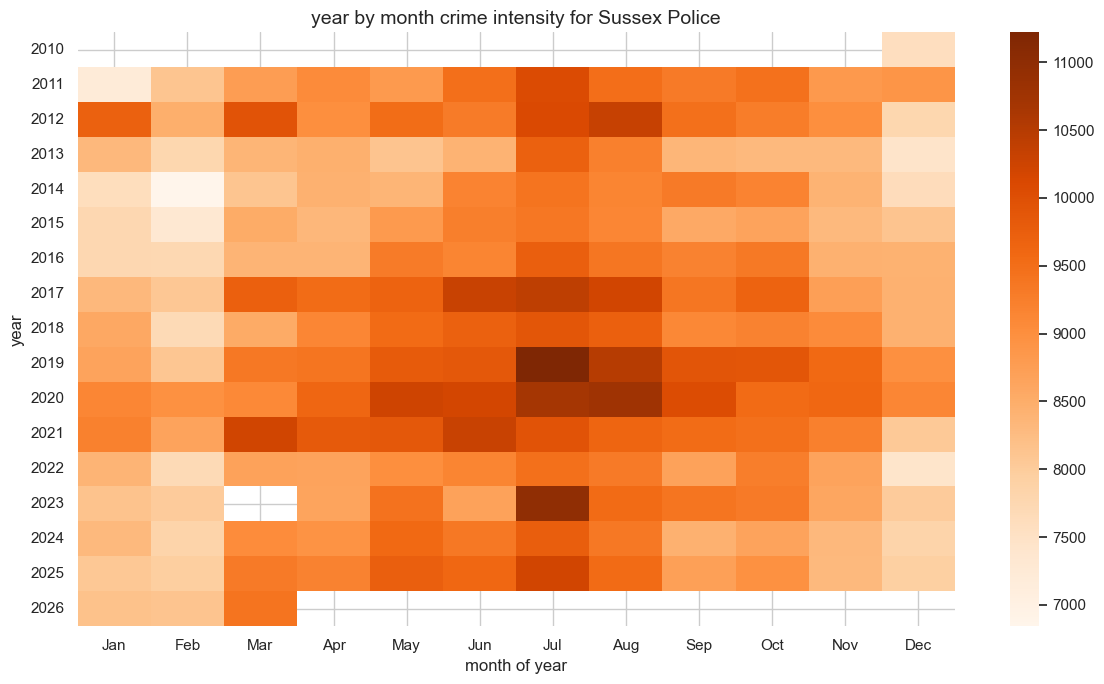

In [29]:
#seasonal heatmap for one force

selected_force = "Sussex Police"

force_heat = monthly_force[monthly_force["police_force"] == selected_force].copy()
force_heat["year"] = force_heat["month"].dt.year
force_heat["month_name"] = force_heat["month"].dt.strftime("%b")

force_heat["month_name"] = pd.Categorical(
    force_heat["month_name"],
    categories=month_order,
    ordered=True
)

pivot_force_heat = force_heat.pivot(index="year", columns="month_name", values="total_crimes")

plt.figure(figsize=(12, 7))
sns.heatmap(pivot_force_heat, cmap="Oranges")
plt.title(f"year by month crime intensity for {selected_force}")
plt.xlabel("month of year")
plt.ylabel("year")
plt.tight_layout()
plt.show()

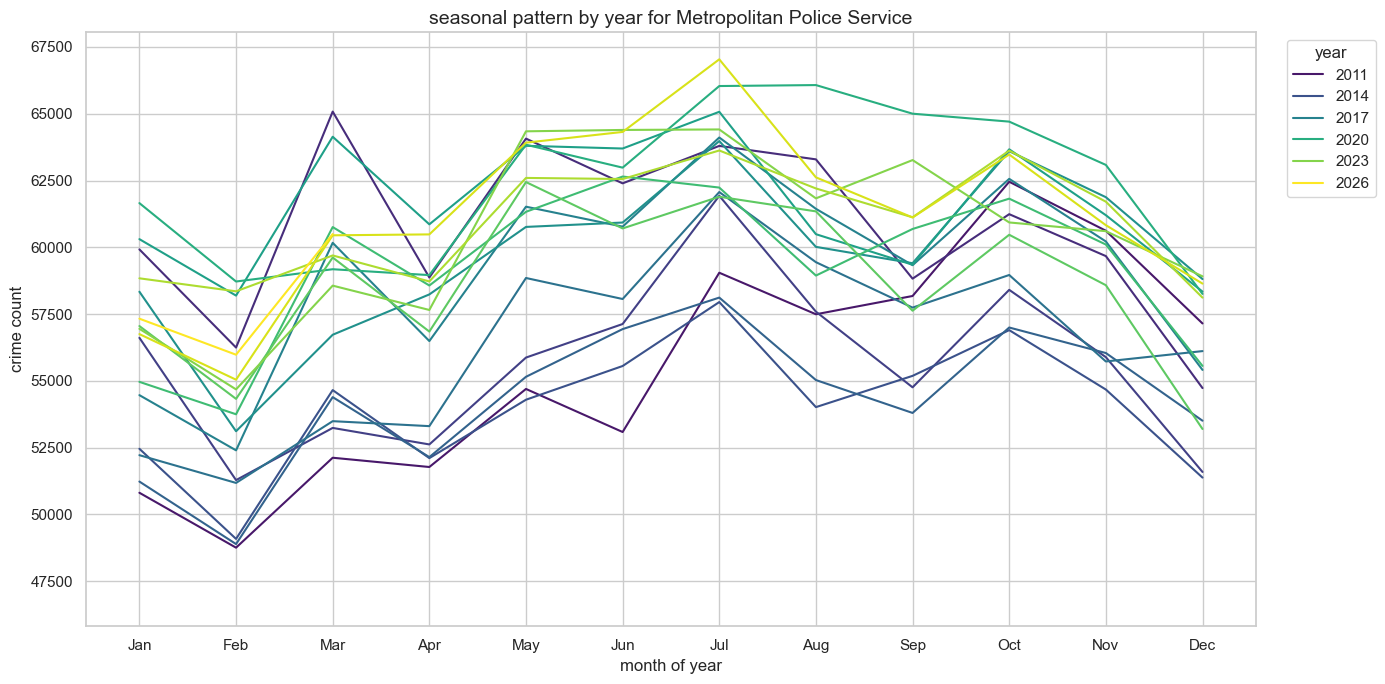

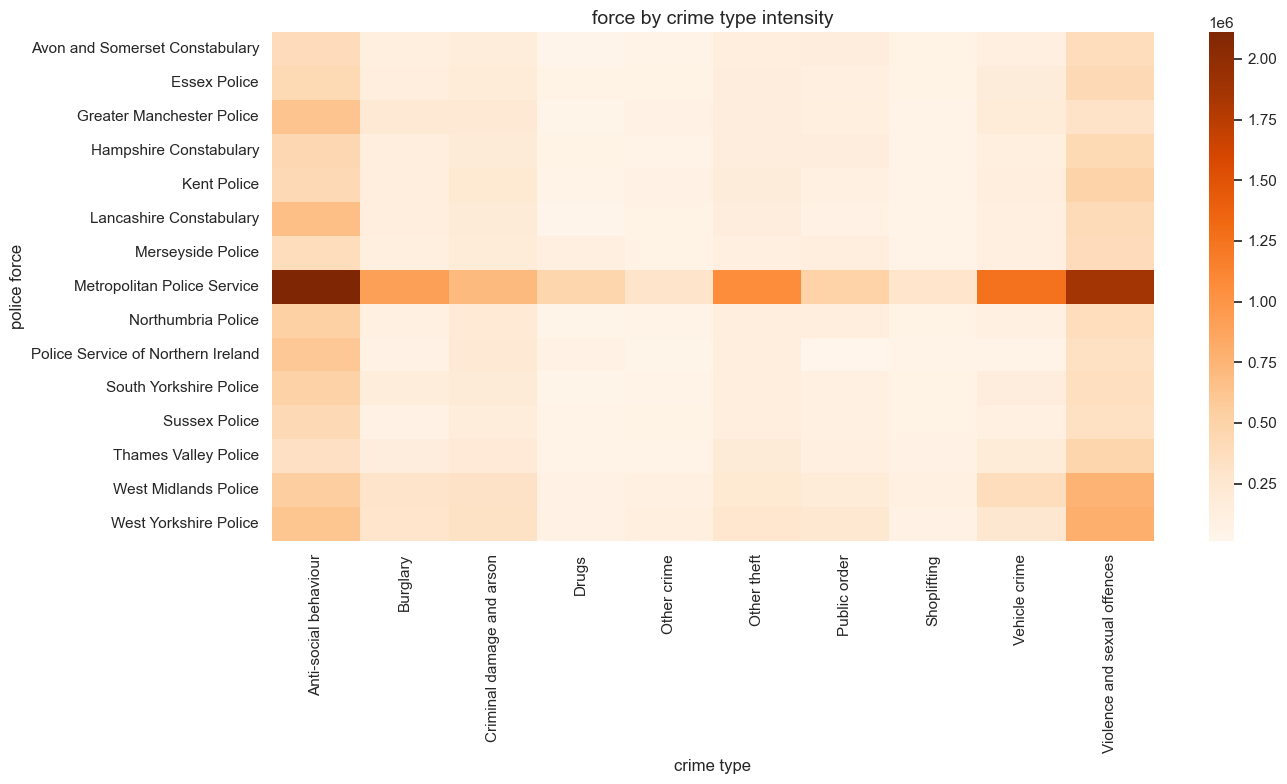

In [ ]:
#force by crime type heatmap

force_type_heat = db.sql(f"""
SELECT
    "Falls within" AS police_force,
    "Crime type" AS crime_type,
    COUNT(*) AS total_crimes
FROM read_parquet('{PARQUET_PATH.as_posix()}')
GROUP BY "Falls within", "Crime type"
""").df()

top_force_heat = (
    force_type_heat.groupby("police_force", as_index=False)["total_crimes"]
    .sum()
    .sort_values("total_crimes", ascending=False)
    .head(15)["police_force"]
    .tolist()
)

top_type_heat = (
    force_type_heat.groupby("crime_type", as_index=False)["total_crimes"]
    .sum()
    .sort_values("total_crimes", ascending=False)
    .head(10)["crime_type"]
    .tolist()
)

force_type_heat_plot = force_type_heat[
    force_type_heat["police_force"].isin(top_force_heat) &
    force_type_heat["crime_type"].isin(top_type_heat)
].copy()

pivot_force_heat = force_type_heat_plot.pivot(index="police_force", columns="crime_type", values="total_crimes").fillna(0)

plt.figure(figsize=(14, 8))
sns.heatmap(pivot_force_heat, cmap="Oranges")
plt.title("force by crime type intensity")
plt.xlabel("crime type")
plt.ylabel("police force")
plt.tight_layout()
plt.show()

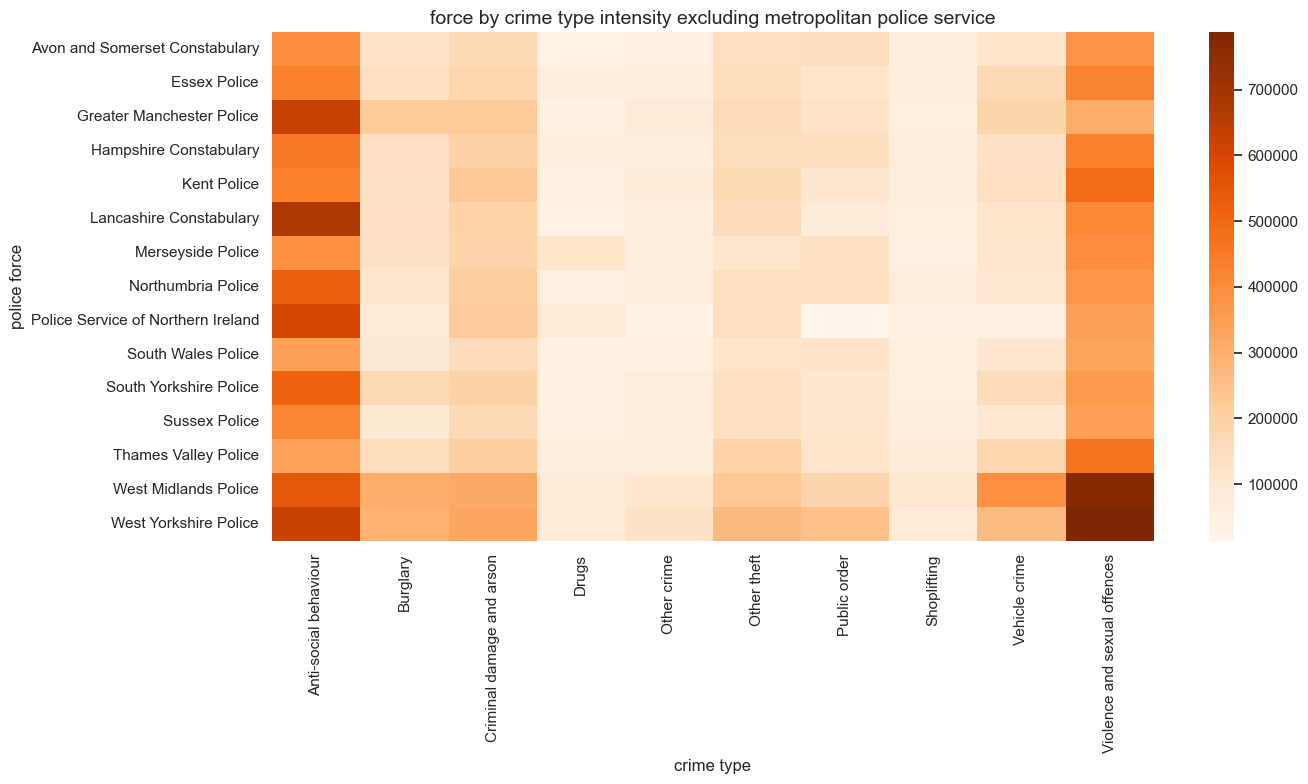

In [ ]:
#force by crime type heatmap excluding metropolitan

force_type_heat = db.sql(f"""
SELECT
    "Falls within" AS police_force,
    "Crime type" AS crime_type,
    COUNT(*) AS total_crimes
FROM read_parquet('{PARQUET_PATH.as_posix()}')
GROUP BY "Falls within", "Crime type"
""").df()

force_type_heat = force_type_heat[
    force_type_heat["police_force"] != "Metropolitan Police Service"
].copy()

top_force_heat = (
    force_type_heat.groupby("police_force", as_index=False)["total_crimes"]
    .sum()
    .sort_values("total_crimes", ascending=False)
    .head(15)["police_force"]
    .tolist()
)

top_type_heat = (
    force_type_heat.groupby("crime_type", as_index=False)["total_crimes"]
    .sum()
    .sort_values("total_crimes", ascending=False)
    .head(10)["crime_type"]
    .tolist()
)

force_type_heat_plot = force_type_heat[
    force_type_heat["police_force"].isin(top_force_heat) &
    force_type_heat["crime_type"].isin(top_type_heat)
].copy()

pivot_force_heat = force_type_heat_plot.pivot(
    index="police_force",
    columns="crime_type",
    values="total_crimes"
).fillna(0)

plt.figure(figsize=(14, 8))
sns.heatmap(pivot_force_heat, cmap="Oranges")
plt.title("force by crime type intensity excluding metropolitan police service")
plt.xlabel("crime type")
plt.ylabel("police force")
plt.tight_layout()
plt.show()